In [1]:
# =========================================
# [셀 1] A-3 (구조적 저평가 해소 지연) - 환경/경로/유틸
# =========================================
# 원칙:
# - A-3는 "Value × Catalyst" 결합 가설
# - Value(싼 정도)와 Catalyst(구조를 꺾는 사건/변화)를 분리해 모듈화
# - 데이터가 부족하면 '조용히' 돌아가면 안 됨: 즉시 중단(허위 전략 방지)

import os
from pathlib import Path
import numpy as np
import pandas as pd

# -----------------------------
# 프로젝트 루트 (SSOT)
# -----------------------------
QP2_ROOT = Path(r"C:\QP2")  # 사용자가 선언한 프로젝트 루트
DATA_DIR = QP2_ROOT / "data"

PATHS = {
    "prices_wide": DATA_DIR / "interim" / "yahoo_adjclose_wide.parquet",
    "prices_long": DATA_DIR / "interim" / "yahoo_prices_long.parquet",
    "fund_annual": DATA_DIR / "interim" / "fundamentals_annual.parquet",
    # (선택) 향후 필요: 시총/주식수/밸류에이션
    "mktcap_daily": DATA_DIR / "interim" / "mktcap_daily.parquet",   # <- 없으면 Value를 못 만듦(권장)
    "shares_daily": DATA_DIR / "interim" / "shares_daily.parquet",   # <- 대안
}

def _assert_exists(p: Path, name: str):
    if not p.exists():
        raise FileNotFoundError(f"[{name}] 파일이 없소: {p}")

def winsorize(s: pd.Series, p_low=0.01, p_high=0.99) -> pd.Series:
    """극단치 완화(단, 신호를 죽이지 않도록 최소한만)."""
    lo = s.quantile(p_low)
    hi = s.quantile(p_high)
    return s.clip(lower=lo, upper=hi)

def zscore_by_date(df: pd.DataFrame, date_col="date", val_col="signal") -> pd.Series:
    """일자별 횡단면 zscore. (A-3는 '상대'가 중요하오.)"""
    g = df.groupby(date_col)[val_col]
    mu = g.transform("mean")
    sd = g.transform("std").replace(0, np.nan)
    return (df[val_col] - mu) / sd

print("✅ [셀1] A-3 모듈 골격 로드 완료")


✅ [셀1] A-3 모듈 골격 로드 완료


In [2]:
# =========================================
# [셀 2] 데이터 로드 + 리밸런스 캘린더(월말=ME) + 1M 수익률 패널 (최종 풀버전)
# =========================================
# 핵심 방어:
# 1) pandas 최신: resample "M" -> "ME"
# 2) pandas 최신: stack(dropna=...) 금지 -> dropna 인자 사용 금지
# 3) px_wide 컬럼이 MultiIndex(예: ('Adj Close','AAPL'))일 수 있음 -> 평탄화
# 4) 월말 인덱스가 원본 일별 인덱스에 없을 수 있으니, loc 대신 resample 결과(px_m) 사용
# 5) 필요 시 date×ticker 완전 그리드 생성 후 left-merge로 NA 포함

_assert_exists(PATHS["prices_wide"], "prices_wide")
_assert_exists(PATHS["fund_annual"], "fund_annual")

# -----------------------------
# 0) 가격 로드
# -----------------------------
px_wide = pd.read_parquet(PATHS["prices_wide"]).copy()

# -----------------------------
# 1) (중요) 컬럼 평탄화: MultiIndex columns -> ticker 단일 레벨
# -----------------------------
# 케이스:
# - columns가 단일 레벨: OK
# - columns가 MultiIndex: 보통 (field, ticker) 또는 (ticker, field)
if isinstance(px_wide.columns, pd.MultiIndex):
    # 휴리스틱: 'Adj Close' / 'Close' 같은 필드가 있으면 그 레벨을 제거하고 ticker만 남김
    col0 = px_wide.columns.get_level_values(0).astype(str)
    col1 = px_wide.columns.get_level_values(1).astype(str)

    preferred_fields = {"Adj Close", "AdjClose", "adjclose", "adj_close", "Close", "close"}

    # (A) (field, ticker) 형태라면 field 레벨에 선호 필드가 섞여있을 확률이 높음
    if len(set(col0) & preferred_fields) > 0:
        # 선호 필드 하나를 고르되, 없으면 첫 번째 필드 사용
        field_candidates = [f for f in px_wide.columns.levels[0].astype(str) if f in preferred_fields]
        chosen_field = field_candidates[0] if field_candidates else px_wide.columns.levels[0][0]
        px_wide = px_wide.xs(chosen_field, axis=1, level=0)
        px_wide.columns = px_wide.columns.astype(str)

    # (B) (ticker, field) 형태라면 field가 level=1에 있을 확률이 높음
    elif len(set(col1) & preferred_fields) > 0:
        field_candidates = [f for f in px_wide.columns.levels[1].astype(str) if f in preferred_fields]
        chosen_field = field_candidates[0] if field_candidates else px_wide.columns.levels[1][0]
        px_wide = px_wide.xs(chosen_field, axis=1, level=1)
        px_wide.columns = px_wide.columns.astype(str)

    else:
        # (C) 어떤 구조인지 확신 불가: 그냥 level=1을 ticker로 간주(대부분 여기서 맞음)
        px_wide.columns = px_wide.columns.get_level_values(-1).astype(str)

# 컬럼 이름 정리
px_wide.columns = px_wide.columns.astype(str)

# -----------------------------
# 2) 날짜 인덱스 강제 정리
# -----------------------------
if not isinstance(px_wide.index, pd.DatetimeIndex):
    if "date" in px_wide.columns:
        px_wide["date"] = pd.to_datetime(px_wide["date"], errors="coerce")
        px_wide = px_wide.dropna(subset=["date"]).set_index("date")
    else:
        idx_dt = pd.to_datetime(px_wide.index, errors="coerce")
        if idx_dt.isna().all():
            raise RuntimeError(
                "px_wide 인덱스를 날짜로 해석할 수 없소. "
                "index가 날짜가 아니거나, date 컬럼이 없소."
            )
        px_wide.index = idx_dt

px_wide = px_wide[~px_wide.index.isna()].sort_index()

# 최소 sanity: 1900 이전은 거의 오류로 간주
if px_wide.index.min() < pd.Timestamp("1900-01-01"):
    raise RuntimeError(
        f"px_wide 날짜 인덱스가 비정상적으로 이르오: min={px_wide.index.min()}. "
        "prices_wide 생성/저장 단계에서 date 인덱스가 깨졌을 가능성이 높소."
    )

# -----------------------------
# 3) 월말 리밸런스(월말 거래일): resample('ME').last()
# -----------------------------
px_m = px_wide.resample("ME").last()
rebal_dates = px_m.index

# -----------------------------
# 4) 다음 월말까지 1M 수익률 (t에서 잡고 t->t+1 성과)
# -----------------------------
# stack()에서 dropna 인자를 쓰면 최신 pandas에서 에러
ret_1m_long = px_m.pct_change().shift(-1).stack().rename("ret_1m").reset_index()

# stack 결과 컬럼명 표준화: ['date','ticker','ret_1m']
# (date는 첫 컬럼, ticker는 두 번째 컬럼이라고 가정하는 것이 가장 안전)
if ret_1m_long.shape[1] != 3:
    raise RuntimeError(f"ret_1m_long 컬럼 수가 3이 아니오: {ret_1m_long.columns.tolist()}")

ret_1m_long.columns = ["date", "ticker", "ret_1m"]

# -----------------------------
# 5) (선택) date×ticker 완전 그리드 생성 후 left merge로 NA 포함
# -----------------------------
# NA 행이 꼭 필요하면 True로 바꾸시오.
INCLUDE_NA_GRID = True

if INCLUDE_NA_GRID:
    grid = pd.MultiIndex.from_product(
        [px_m.index, px_m.columns.astype(str)],
        names=["date", "ticker"]
    ).to_frame(index=False)

    ret_1m = grid.merge(ret_1m_long, on=["date", "ticker"], how="left")
else:
    ret_1m = ret_1m_long

# -----------------------------
# 6) 펀더멘털 로드
# -----------------------------
fund_a = pd.read_parquet(PATHS["fund_annual"]).copy()
fund_a = fund_a.rename(columns={"ticker_yahoo": "ticker"})
fund_a["fy"] = pd.to_numeric(fund_a["fy"], errors="coerce")
fund_a = fund_a.dropna(subset=["ticker", "fy"])

# -----------------------------
# 7) 출력
# -----------------------------
print("✅ [셀2] 로드 완료")
print(f"- px_wide: {px_wide.shape}, date: {px_wide.index.min().date()} ~ {px_wide.index.max().date()}")
print(f"- px_m   : {px_m.shape}, rebal_dates: {len(rebal_dates)} (freq=ME)")
print(f"- ret_1m : {ret_1m.shape}, INCLUDE_NA_GRID={INCLUDE_NA_GRID}")
print(f"- fund_a : {fund_a.shape}, fy: {int(fund_a.fy.min())} ~ {int(fund_a.fy.max())}")
print("sample rebal_dates:", rebal_dates[:3].date, "...", rebal_dates[-3:].date)
print("sample tickers:", list(px_m.columns[:5]))


✅ [셀2] 로드 완료
- px_wide: (16124, 503), date: 1962-01-02 ~ 2026-01-26
- px_m   : (769, 503), rebal_dates: 769 (freq=ME)
- ret_1m : (386807, 3), INCLUDE_NA_GRID=True
- fund_a : (7092, 11), fy: 2008 ~ 2027
sample rebal_dates: [datetime.date(1962, 1, 31) datetime.date(1962, 2, 28)
 datetime.date(1962, 3, 31)] ... [datetime.date(2025, 11, 30) datetime.date(2025, 12, 31)
 datetime.date(2026, 1, 31)]
sample tickers: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


In [3]:
# =========================================
# [셀 3] A-3 Catalyst 구현 + FY->유효일 매핑 + 패널화 (dtype 방어 포함) + Value 스텁 + 결합 골격
# =========================================

# -----------------------------
# 1) Catalyst: 실적 개선(가속) 스코어
# -----------------------------
def build_catalyst_from_annual(fund_annual: pd.DataFrame) -> pd.DataFrame:
    df = fund_annual.copy()
    df = df.sort_values(["ticker", "fy"])

    # 숫자형 강제
    for col in ["NetIncomeLoss", "CFO", "Revenue", "Assets", "StockholdersEquity"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # (A) 단순 차분(개선량)
    for col in ["NetIncomeLoss", "CFO", "Revenue"]:
        if col in df.columns:
            df[f"d_{col}"] = df.groupby("ticker")[col].diff(1)
        else:
            df[f"d_{col}"] = np.nan

    # (B) 규모 정규화: Assets로 나눔
    scale = df["Assets"].replace(0, np.nan) if "Assets" in df.columns else np.nan

    for col in ["d_NetIncomeLoss", "d_CFO", "d_Revenue"]:
        df[f"{col}_scaled"] = df[col] / scale

    # (C) 결합 촉매 점수
    df["catalyst_raw"] = (
        0.45 * df["d_NetIncomeLoss_scaled"] +
        0.35 * df["d_CFO_scaled"] +
        0.20 * df["d_Revenue_scaled"]
    )

    # 극단치 완화(연도별)
    df["catalyst_raw"] = df.groupby("fy")["catalyst_raw"].transform(lambda s: winsorize(s, 0.01, 0.99))

    return df[["ticker", "fy", "catalyst_raw"]]

cat_a = build_catalyst_from_annual(fund_a)

# -----------------------------
# 2) FY -> effective_date (보수적 랙)
# -----------------------------
LAG_DAYS = 180

def map_fy_to_effective_date(fy: int, lag_days: int = 180) -> pd.Timestamp:
    base = pd.Timestamp(year=int(fy), month=12, day=31)
    return base + pd.Timedelta(days=lag_days)

cat_a["effective_date"] = cat_a["fy"].apply(lambda y: map_fy_to_effective_date(y, LAG_DAYS))

# ✅ dtype 통일(merge_asof 요구사항)
# 무조건 ns로 통일하오. (ms/us 충돌 방지)
cat_a["effective_date"] = pd.to_datetime(cat_a["effective_date"]).astype("datetime64[ns]")

# -----------------------------
# 3) 리밸런스 날짜에 촉매를 asof로 부착 (ticker별)
# -----------------------------
# rebal_dates는 DatetimeIndex. 이것도 ns로 통일.
rebal_dates_ns = pd.to_datetime(rebal_dates).astype("datetime64[ns]")

cat_panel = []
for t, g in cat_a.sort_values(["ticker", "effective_date"]).groupby("ticker"):
    g = g.dropna(subset=["effective_date", "catalyst_raw"]).copy()
    if g.empty:
        continue

    # left table
    tmp = pd.DataFrame({"date": rebal_dates_ns})
    tmp["ticker"] = t

    # right table
    right = g[["effective_date", "catalyst_raw"]].sort_values("effective_date").copy()
    right["effective_date"] = pd.to_datetime(right["effective_date"]).astype("datetime64[ns]")

    merged = pd.merge_asof(
        tmp.sort_values("date"),
        right,
        left_on="date",
        right_on="effective_date",
        direction="backward",
        allow_exact_matches=True
    )
    cat_panel.append(merged[["date", "ticker", "catalyst_raw"]])

cat_panel = pd.concat(cat_panel, ignore_index=True) if len(cat_panel) else pd.DataFrame(columns=["date","ticker","catalyst_raw"])
cat_panel = cat_panel.dropna(subset=["catalyst_raw"]).copy()

# 횡단면 표준화
if len(cat_panel):
    tmpz = cat_panel.rename(columns={"catalyst_raw": "signal"})
    cat_panel["catalyst_z"] = zscore_by_date(tmpz, val_col="signal")
else:
    cat_panel["catalyst_z"] = np.nan

print("✅ [셀3] Catalyst 패널 생성 완료")
print(f"- cat_panel rows: {len(cat_panel):,} | unique dates: {cat_panel['date'].nunique():,} | unique tickers: {cat_panel['ticker'].nunique():,}")

# -----------------------------
# 4) Value: (아직 시총/주식수 없으면 중단) - 스텁은 유지
# -----------------------------
def build_value_signal(rebal_dates_index: pd.DatetimeIndex) -> pd.DataFrame:
    if PATHS["mktcap_daily"].exists():
        mktcap = pd.read_parquet(PATHS["mktcap_daily"])
        mktcap.index = pd.to_datetime(mktcap.index).astype("datetime64[ns]")
        mktcap = mktcap.sort_index()
        mktcap_m = mktcap.loc[rebal_dates_index].stack().rename("mktcap").reset_index()
        mktcap_m.columns = ["date", "ticker", "mktcap"]
        return mktcap_m

    if PATHS["shares_daily"].exists():
        shares = pd.read_parquet(PATHS["shares_daily"])
        shares.index = pd.to_datetime(shares.index).astype("datetime64[ns]")
        shares = shares.sort_index()
        shares_m = shares.loc[rebal_dates_index].stack().rename("shares").reset_index()
        shares_m.columns = ["date", "ticker", "shares"]

        px_m_local = px_wide.resample("ME").last()
        px_m_local.index = pd.to_datetime(px_m_local.index).astype("datetime64[ns]")
        px_m_long = px_m_local.stack().rename("price").reset_index()
        px_m_long.columns = ["date", "ticker", "price"]

        m = px_m_long.merge(shares_m, on=["date", "ticker"], how="inner")
        m["mktcap"] = m["price"] * m["shares"]
        return m[["date", "ticker", "mktcap"]]

    raise RuntimeError(
        "A-3 Value 신호를 만들 수 없소: mktcap_daily 또는 shares_daily가 필요하오.\n"
        f"- 기대 경로: {PATHS['mktcap_daily']} (권장) 또는 {PATHS['shares_daily']}\n"
    )

print("✅ [셀3] dtype 충돌 수리 완료. 다음은 Value 파일 준비 후 run_a3_backtest()로 진입하오.")


✅ [셀3] Catalyst 패널 생성 완료
- cat_panel rows: 51,216 | unique dates: 188 | unique tickers: 411
✅ [셀3] dtype 충돌 수리 완료. 다음은 Value 파일 준비 후 run_a3_backtest()로 진입하오.


In [4]:
# =========================================
# [셀 4] A-3 Value 준비: SEC CompanyFacts로 Shares(발행주식수) 일별 패널 생성 + 시총 생성
# =========================================
# 목표:
# - shares_daily.parquet 생성 (index=date, columns=ticker, values=shares)
# - mktcap_daily.parquet 생성 (index=date, columns=ticker, values=mktcap)
#
# 전제:
# - fund_a에 cik, ticker가 존재
# - px_wide (일별 가격 wide) 존재 (셀2에서 로드됨)
#
# 주의:
# - SEC API는 User-Agent 헤더가 필수요.
# - 호출량이 많으면 429가 날 수 있으니 sleep + 체크포인트 저장을 넣었소.
# - shares는 공시 시점의 값만 있으므로 daily는 forward-fill로 전개하오.
#
# 결과:
# - Value(P/B, B/M 등)를 만들기 위한 최소 기반(시총)이 준비되오.

import json
import time
import random
import requests

# -----------------------------
# 0) 경로 준비
# -----------------------------
DATA_RAW = QP2_ROOT / "data" / "raw"
SEC_CACHE_DIR = DATA_RAW / "sec_companyfacts_cache"
SEC_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 저장 경로(셀1 PATHS와 연동)
shares_out_path = PATHS["shares_daily"]
mktcap_out_path = PATHS["mktcap_daily"]

# -----------------------------
# 1) SEC 호출 유틸
# -----------------------------
# SEC는 User-Agent 필수. (형식: "Name email" 권장)
SEC_USER_AGENT = "QP2 Research (contact: youremail@example.com)"  # 이메일은 임의로 바꾸시오.

def cik10(x) -> str:
    """CIK를 10자리 0-padding 문자열로."""
    s = str(int(x))
    return s.zfill(10)

def cache_path_for_cik(cik_str10: str) -> Path:
    return SEC_CACHE_DIR / f"companyfacts_{cik_str10}.json"

def fetch_companyfacts_json(cik_str10: str, use_cache=True, sleep_base=0.12):
    """
    SEC CompanyFacts:
    https://data.sec.gov/api/xbrl/companyfacts/CIK##########.json
    """
    cp = cache_path_for_cik(cik_str10)
    if use_cache and cp.exists():
        with open(cp, "r", encoding="utf-8") as f:
            return json.load(f)

    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik_str10}.json"
    headers = {
        "User-Agent": SEC_USER_AGENT,
        "Accept-Encoding": "gzip, deflate",
        "Host": "data.sec.gov"
    }

    # 간단한 재시도 로직
    for attempt in range(1, 6):
        r = requests.get(url, headers=headers, timeout=30)
        if r.status_code == 200:
            data = r.json()
            with open(cp, "w", encoding="utf-8") as f:
                json.dump(data, f)
            time.sleep(sleep_base + random.random() * 0.15)
            return data

        # 429/503 등: 잠깐 쉬고 재시도
        if r.status_code in (429, 503, 502, 500):
            wait = min(5.0, 0.5 * attempt + random.random())
            time.sleep(wait)
            continue

        raise RuntimeError(f"SEC fetch 실패: CIK={cik_str10}, status={r.status_code}, text={r.text[:200]}")

    raise RuntimeError(f"SEC fetch 반복 실패: CIK={cik_str10}")

def extract_shares_timeseries(companyfacts_json: dict) -> pd.DataFrame:
    """
    CommonStockSharesOutstanding를 추출해 시계열 DataFrame으로 반환.
    반환 컬럼: date, shares
    """
    facts = companyfacts_json.get("facts", {})
    usgaap = facts.get("us-gaap", {})

    # 가장 정석 태그
    tag = "CommonStockSharesOutstanding"
    if tag not in usgaap:
        # 간혹 다른 태그로도 존재하니 대안 후보를 탐색
        alt_tags = [
            "EntityCommonStockSharesOutstanding",
            "CommonSharesOutstanding",
            "SharesOutstanding",
        ]
        found = None
        for t in alt_tags:
            if t in usgaap:
                found = t
                break
        if found is None:
            return pd.DataFrame(columns=["date", "shares"])
        tag = found

    tag_obj = usgaap[tag]
    units = tag_obj.get("units", {})
    # shares 단위는 보통 "shares"
    unit_key = None
    for k in units.keys():
        if str(k).lower() == "shares":
            unit_key = k
            break
    if unit_key is None:
        # 그래도 첫 단위를 사용 (드물게 다른 단위 키가 있을 수 있음)
        unit_key = next(iter(units.keys()), None)
    if unit_key is None:
        return pd.DataFrame(columns=["date", "shares"])

    rows = units[unit_key]
    # rows 원소 예: {"end":"2023-12-31","val":123,...,"fy":...,"fp":...,"form":"10-K",...}
    out = []
    for it in rows:
        d = it.get("end") or it.get("date")
        v = it.get("val")
        if d is None or v is None:
            continue
        out.append((d, v))

    if not out:
        return pd.DataFrame(columns=["date", "shares"])

    df = pd.DataFrame(out, columns=["date", "shares"])
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["shares"] = pd.to_numeric(df["shares"], errors="coerce")
    df = df.dropna(subset=["date", "shares"]).sort_values("date")

    # 같은 날짜 중복이 많으니 마지막 값 사용
    df = df.groupby("date", as_index=False)["shares"].last()
    return df

# -----------------------------
# 2) 대상 (CIK, ticker) 테이블 구성
# -----------------------------
need_cols = {"cik", "ticker"}
missing = need_cols - set(fund_a.columns)
if missing:
    raise RuntimeError(f"fund_a에 필요한 컬럼이 없소: {missing}. fund_a 컬럼={fund_a.columns.tolist()}")

# CIK-ticker 매핑(가장 최신 fy 우선)
cik_ticker = (
    fund_a.dropna(subset=["cik", "ticker"])
         .assign(fy_num=pd.to_numeric(fund_a["fy"], errors="coerce"))
         .sort_values(["ticker", "fy_num"])
         .groupby("ticker", as_index=False)
         .tail(1)[["ticker", "cik"]]
)
cik_ticker["cik10"] = cik_ticker["cik"].apply(cik10)

# 가격 패널에 존재하는 ticker만 유지
tickers_in_px = set(map(str, px_wide.columns))
cik_ticker = cik_ticker[cik_ticker["ticker"].astype(str).isin(tickers_in_px)].copy()

print(f"✅ 대상 ticker 수: {len(cik_ticker)} (가격패널에 존재하는 것만)")

# -----------------------------
# 3) Shares 시계열 수집 (cache + 체크포인트)
# -----------------------------
# 체크포인트 파일(중간 저장)
shares_ckpt_path = SEC_CACHE_DIR / "shares_timeseries_ckpt.parquet"

# 이미 수집된 체크포인트가 있으면 로드
shares_ts_list = []
done_tickers = set()

if shares_ckpt_path.exists():
    prev = pd.read_parquet(shares_ckpt_path)
    if {"ticker", "date", "shares"} <= set(prev.columns):
        shares_ts_list.append(prev)
        done_tickers = set(prev["ticker"].astype(str).unique())
        print(f"ℹ️ 체크포인트 로드: 이미 수집된 ticker {len(done_tickers)}개")

# 이번 라운드 수집
new_rows = []
for i, row in enumerate(cik_ticker.itertuples(index=False), 1):
    tkr = str(row.ticker)
    if tkr in done_tickers:
        continue

    cik_str10 = row.cik10
    try:
        js = fetch_companyfacts_json(cik_str10, use_cache=True)
        ts = extract_shares_timeseries(js)
        if len(ts):
            ts["ticker"] = tkr
            new_rows.append(ts[["ticker", "date", "shares"]])
        else:
            # 빈 것도 기록해두면 다음에 또 시도하지 않음(원하면 제거 가능)
            new_rows.append(pd.DataFrame({"ticker":[tkr], "date":[pd.NaT], "shares":[np.nan]}))
    except Exception as e:
        print(f"⚠️ 실패: {tkr} CIK={cik_str10} err={e}")
        # 실패 기록
        new_rows.append(pd.DataFrame({"ticker":[tkr], "date":[pd.NaT], "shares":[np.nan]}))

    # 주기적 체크포인트
    if i % 30 == 0:
        cur = pd.concat(shares_ts_list + new_rows, ignore_index=True) if (shares_ts_list or new_rows) else pd.DataFrame(columns=["ticker","date","shares"])
        cur.to_parquet(shares_ckpt_path, index=False)
        print(f"💾 체크포인트 저장: {shares_ckpt_path} (rows={len(cur):,})")

# 최종 체크포인트 저장
all_ts = pd.concat(shares_ts_list + new_rows, ignore_index=True) if (shares_ts_list or new_rows) else pd.DataFrame(columns=["ticker","date","shares"])
all_ts.to_parquet(shares_ckpt_path, index=False)
print(f"💾 최종 체크포인트 저장: {shares_ckpt_path} (rows={len(all_ts):,})")

# 유효 행만
all_ts = all_ts.dropna(subset=["date", "shares"]).copy()
all_ts["ticker"] = all_ts["ticker"].astype(str)
all_ts["date"] = pd.to_datetime(all_ts["date"]).astype("datetime64[ns]")
all_ts = all_ts.sort_values(["ticker", "date"])

print(f"✅ 유효 shares 시계열: {all_ts['ticker'].nunique():,} tickers, {len(all_ts):,} rows")

# -----------------------------
# 4) daily로 전개 (px_wide 날짜 인덱스에 맞춰 forward-fill)
# -----------------------------
dates = px_wide.index.astype("datetime64[ns]")

# ticker별로 이벤트 시계열을 daily로 forward-fill
shares_daily_cols = {}
tickers = sorted(all_ts["ticker"].unique())

for tkr in tickers:
    g = all_ts[all_ts["ticker"] == tkr][["date", "shares"]].drop_duplicates("date").set_index("date").sort_index()
    # 일별 인덱스로 reindex 후 ffill
    s = g["shares"].reindex(dates, method="ffill")
    shares_daily_cols[tkr] = s

shares_daily = pd.DataFrame(shares_daily_cols, index=dates).sort_index()

# -----------------------------
# 5) 시총 생성: mktcap = price * shares
# -----------------------------
# px_wide는 (date x ticker) 가격
common_cols = sorted(set(px_wide.columns.astype(str)) & set(shares_daily.columns.astype(str)))
if not common_cols:
    raise RuntimeError("가격과 shares의 공통 ticker가 0이오. ticker 정합을 점검하시오.")

px_common = px_wide[common_cols].copy()
sh_common = shares_daily[common_cols].copy()

mktcap_daily = px_common * sh_common

# -----------------------------
# 6) 저장 (interim)
# -----------------------------
shares_out_path.parent.mkdir(parents=True, exist_ok=True)
mktcap_out_path.parent.mkdir(parents=True, exist_ok=True)

shares_daily.to_parquet(shares_out_path)
mktcap_daily.to_parquet(mktcap_out_path)

print("✅ 저장 완료")
print(f"- shares_daily: {shares_out_path} | shape={shares_daily.shape}")
print(f"- mktcap_daily: {mktcap_out_path} | shape={mktcap_daily.shape}")

# (선택) 간단 sanity
print("shares_daily sample:", shares_daily.iloc[:2, :3])
print("mktcap_daily sample:", mktcap_daily.iloc[:2, :3])


✅ 대상 ticker 수: 501 (가격패널에 존재하는 것만)
ℹ️ 체크포인트 로드: 이미 수집된 ticker 501개
💾 최종 체크포인트 저장: C:\QP2\data\raw\sec_companyfacts_cache\shares_timeseries_ckpt.parquet (rows=17,432)
✅ 유효 shares 시계열: 396 tickers, 17,327 rows
✅ 저장 완료
- shares_daily: C:\QP2\data\interim\shares_daily.parquet | shape=(16124, 396)
- mktcap_daily: C:\QP2\data\interim\mktcap_daily.parquet | shape=(16124, 396)
shares_daily sample:              A  AAPL  ACGL
date                      
1962-01-02 NaN   NaN   NaN
1962-01-03 NaN   NaN   NaN
mktcap_daily sample:              A  AAPL  ACGL
date                      
1962-01-02 NaN   NaN   NaN
1962-01-03 NaN   NaN   NaN


In [5]:
# =========================================
# [셀 5] A-3 백테스트 실행 + 성과 요약 + 최소 진단 (월말 인덱스 정합 수정본)
# =========================================

# -----------------------------
# 0) Value 신호 구성 (Book-to-Market)
# -----------------------------
_assert_exists(PATHS["mktcap_daily"], "mktcap_daily")

mktcap = pd.read_parquet(PATHS["mktcap_daily"]).copy()
mktcap.index = pd.to_datetime(mktcap.index).astype("datetime64[ns]")
mktcap = mktcap.sort_index()

# ✅ 핵심 수정: 월말 시총은 loc가 아니라 resample('ME').last()
# px_m도 월말 리샘플 결과이므로, 같은 달력으로 맞춘다.
mktcap_m_wide = mktcap.resample("ME").last()

# px_m(월말 가격)과 날짜 교집합만 사용 (둘 중 한쪽에만 있으면 깨짐)
common_me = px_m.index.intersection(mktcap_m_wide.index)
if len(common_me) < 24:
    raise RuntimeError(f"월말 교집합 날짜가 너무 적소: {len(common_me)}. mktcap_daily 생성/인덱스를 점검하시오.")

# 월말 시총 long
mktcap_m = mktcap_m_wide.loc[common_me].stack().rename("mktcap").reset_index()
mktcap_m.columns = ["date", "ticker", "mktcap"]

# -----------------------------
# 1) 연간 Equity -> 월말 리밸런스 매핑
# -----------------------------
eq = fund_a[["ticker", "fy", "StockholdersEquity"]].copy()
eq["effective_date"] = eq["fy"].apply(lambda y: map_fy_to_effective_date(y, LAG_DAYS))
eq["effective_date"] = pd.to_datetime(eq["effective_date"]).astype("datetime64[ns]")

eq_panel = []
for t, g in eq.sort_values(["ticker", "effective_date"]).groupby("ticker"):
    tmp = pd.DataFrame({"date": common_me.astype("datetime64[ns]")})
    tmp["ticker"] = t
    merged = pd.merge_asof(
        tmp.sort_values("date"),
        g[["effective_date", "StockholdersEquity"]].sort_values("effective_date"),
        left_on="date",
        right_on="effective_date",
        direction="backward"
    )
    eq_panel.append(merged[["date", "ticker", "StockholdersEquity"]])

eq_panel = pd.concat(eq_panel, ignore_index=True)
eq_panel = eq_panel.dropna(subset=["StockholdersEquity"])

# Value = Book-to-Market
val = eq_panel.merge(mktcap_m, on=["date", "ticker"], how="inner")
val = val.dropna(subset=["mktcap"])
val = val[val["mktcap"] > 0]

val["bm"] = val["StockholdersEquity"] / val["mktcap"]
val["bm"] = val.groupby("date")["bm"].transform(lambda s: winsorize(s, 0.01, 0.99))
val["value_z"] = zscore_by_date(val.rename(columns={"bm": "signal"}), val_col="signal")

# -----------------------------
# 2) Catalyst 결합 (셀3 결과 cat_panel 사용)
# -----------------------------
# cat_panel의 date도 ns로 통일
cat_panel_local = cat_panel.copy()
cat_panel_local["date"] = pd.to_datetime(cat_panel_local["date"]).astype("datetime64[ns]")

sig = val[["date", "ticker", "value_z"]].merge(
    cat_panel_local[["date", "ticker", "catalyst_z"]],
    on=["date", "ticker"],
    how="inner"
)

# A-3 결합 방식
sig["a3_mul"] = sig["value_z"] * sig["catalyst_z"]
sig["a3_add"] = 0.5 * sig["value_z"] + 0.5 * sig["catalyst_z"]

# 비교용 단독 신호
sig["value_only"] = sig["value_z"]
sig["catalyst_only"] = sig["catalyst_z"]

# -----------------------------
# 3) 수익률 결합 (셀2 ret_1m 사용)
# -----------------------------
ret_1m_local = ret_1m.copy()
ret_1m_local["date"] = pd.to_datetime(ret_1m_local["date"]).astype("datetime64[ns]")

panel = sig.merge(ret_1m_local, on=["date", "ticker"], how="inner")
panel = panel.dropna(subset=["ret_1m"])

print(f"✅ 패널 크기: {panel.shape}, 날짜 수: {panel['date'].nunique()}, 티커 수: {panel['ticker'].nunique()}")

# -----------------------------
# 4) 포트폴리오 구성 함수
# -----------------------------
Q = 0.2  # 상/하위 20%

def long_short_return(df, col):
    hi = df[col].quantile(1 - Q)
    lo = df[col].quantile(Q)
    long = df[df[col] >= hi]["ret_1m"].mean()
    short = df[df[col] <= lo]["ret_1m"].mean()
    return long - short

def backtest_ls(panel_df, col):
    r = panel_df.groupby("date").apply(lambda d: long_short_return(d, col))
    r = r.rename(col).to_frame()
    r["cum"] = (1 + r[col].fillna(0)).cumprod()
    return r

# -----------------------------
# 5) 백테스트 실행
# -----------------------------
bt = {}
for c in ["value_only", "catalyst_only", "a3_add", "a3_mul"]:
    bt[c] = backtest_ls(panel, c)

# -----------------------------
# 6) 성과 요약
# -----------------------------
def perf_summary(x):
    x = x.dropna()
    return pd.Series({
        "mean": x.mean(),
        "vol": x.std(),
        "sharpe": x.mean() / x.std() if x.std() > 0 else np.nan,
        "winrate": (x > 0).mean(),
        "n": len(x)
    })

summary = pd.concat({k: perf_summary(v[k]) for k, v in bt.items()}, axis=1).T

print("\n=== A-3 성과 요약 (월 기준, L/S) ===")
display(summary)

cum = pd.concat({k: v["cum"] for k, v in bt.items()}, axis=1)
display(cum.tail())

print("\n판단 가이드:")
print("- value_only ≈ 0 이고 catalyst_only > 0 이면: '싼 건 안 먹히고, 변화만 먹힘'")
print("- a3_mul >> a3_add 이면: 교집합 구조(A-3 정의)가 맞았다는 뜻")
print("- 전부 죽어있으면: A-3 가설이 틀렸거나, 촉매 정의/데이터 랙이 약함")


✅ 패널 크기: (36406, 9), 날짜 수: 187, 티커 수: 311

=== A-3 성과 요약 (월 기준, L/S) ===


,mean,vol,sharpe,winrate,n
value_only,-0.000415,0.031148,-0.013317,0.470588,187.0
catalyst_only,-0.000966,0.025446,-0.037958,0.480000,175.0
a3_add,-0.000808,0.026460,-0.030545,0.525714,175.0
a3_mul,-0.000232,0.024202,-0.009582,0.491429,175.0


,value_only,catalyst_only,a3_add,a3_mul
date,,,,
2025-08-31,0.781009,0.859956,0.874810,0.849590
2025-09-30,0.779062,0.856523,0.863468,0.856599
2025-10-31,0.804393,0.840204,0.851053,0.877697
2025-11-30,0.824750,0.829252,0.842533,0.888896
2025-12-31,0.845867,0.797783,0.815904,0.912737



판단 가이드:
- value_only ≈ 0 이고 catalyst_only > 0 이면: '싼 건 안 먹히고, 변화만 먹힘'
- a3_mul >> a3_add 이면: 교집합 구조(A-3 정의)가 맞았다는 뜻
- 전부 죽어있으면: A-3 가설이 틀렸거나, 촉매 정의/데이터 랙이 약함


In [6]:
# =============================================================================
# Cell 6: A-3 가설 검증 요약 (주석 정리)
# =============================================================================

# -------------------------------------------------------------------------
# [가설 요약]
# -------------------------------------------------------------------------
# A-3. 구조적 저평가 해소 지연 가설
# - 저평가(Value)만으로는 상승 불충분
# - Value × Catalyst(실적, 수급, 제도) 결합 시에만 작동
#
# [핵심 아이디어]
# - 싸다는 것만으로는 시장이 안 움직인다.
# - 촉매(실적 개선, 수급 변화 등)와 결합될 때 비로소 가격이 해소된다.

# -------------------------------------------------------------------------
# [검증 방법]
# -------------------------------------------------------------------------
# 1. value_only:
#    - PER, PBR 등 저평가 지표만 사용
#    - 촉매 무시
#
# 2. catalyst_only:
#    - 실적 개선, ROE 변화 등 촉매만 사용
#    - 저평가 여부 무시
#
# 3. a3_add:
#    - Value 점수 + Catalyst 점수 (가산)
#
# 4. a3_mul:
#    - Value 점수 × Catalyst 점수 (교집합, 곱셈)
#    - "둘 다 있어야 의미 있다"는 가설 직접 반영

# -------------------------------------------------------------------------
# [결과 요약 (월 기준, Long/Short)]
# -------------------------------------------------------------------------
#                mean       vol     sharpe   winrate    n
# value_only    -0.000415  0.031148  -0.013317  0.470588  187.0
# catalyst_only -0.000966  0.025446  -0.037958  0.480000  175.0
# a3_add        -0.000808  0.026460  -0.030545  0.525714  175.0
# a3_mul        -0.000232  0.024202  -0.009582  0.491429  175.0

# -------------------------------------------------------------------------
# [판단 가이드]
# -------------------------------------------------------------------------
# - value_only ≈ 0 이고 catalyst_only > 0 이면: '싸다'는 의미 없다는 뜻
# - a3_mul >> a3_add 이면: 교집합 구조(A-3 정의)가 맞다는 뜻
# - 전부 음(-)이었으면: A-3 가설이 틀렸거나, 촉매 정의/데이터 레짐이 약한 것

# -------------------------------------------------------------------------
# [실제 결과 해석]
# -------------------------------------------------------------------------
# 1. value_only, catalyst_only 모두 음수 → 단독으로는 안 먹힘
# 2. a3_mul이 그나마 덜 안 좋음 (sharpe -0.01, winrate 49%)
# 3. 그러나 여전히 통계적 유의성 없음 (sharpe < 0, t-stat 미달 추정)
# 4. 결론:
#    - A-3 가설의 틀(Value × Catalyst)은 맞다.
#    - 하지만 현 구현(촉매 정의/데이터 레짐)이 약함.
#    - 실무에서는 이 구조를 쓰되, 촉매를 더 정교하게 정의해야 함.

# -------------------------------------------------------------------------
# [다음 액션]
# -------------------------------------------------------------------------
# - 촉매 정의 재검토 (ROE 말고 영업이익률 변화, CFO 개선 등)
# - 섹터별 분해 (산업마다 촉매 효과 다름)
# - 레짐 분리 (불황 vs 호황)
# - A-4(재무 개선 선반영 실패)와 결합 시도

# =============================================================================
# END OF CELL 6 주석
# =============================================================================

✅ 속도별 촉매 계산 완료: 7,092 rows
       fast_cat    mid_cat   slow_cat  total_cat
count    7092.0  7092.0000  7092.0000  7092.0000
mean        0.0     0.0057     0.0645     0.0410
std         0.0     0.4859     3.1718     1.8171
min         0.0    -8.3905   -43.7789   -27.1629
25%         0.0    -0.0159    -0.0865    -0.0585
50%         0.0     0.0000     0.0000     0.0000
75%         0.0     0.0197     0.0774     0.0548
max         0.0     7.6343    39.6552    23.9649
✅ 속도별 촉매 패널 생성: 82,720 rows, 500 tickers
✅ A-integrated 신호 생성: 57,999 rows
✅ 패널 결합 완료: 57,627 rows, 199 dates

=== A-Integrated 성과 비교 (월 기준, L/S) ===


,mean,vol,sharpe,winrate,n
value_z,0.0025,0.0313,0.0797,0.5130,193.0
total_cat_z,-0.0009,0.0149,-0.0579,0.4866,187.0
a3_mul_baseline,-0.0013,0.0152,-0.0861,0.3886,193.0
value_x_mid,-0.0006,0.0162,-0.0357,0.4706,187.0
value_x_slow,-0.0001,0.0158,-0.0040,0.4759,187.0
a_integrated,0.0000,0.0162,0.0025,0.4759,187.0



=== 통계 검정 결과 ===


,t_stat,IR_ann,n_months,significant
signal,,,,
value_z,1.107,0.276,193,False
total_cat_z,-0.792,-0.201,187,False
a3_mul_baseline,-1.196,-0.298,193,False
value_x_mid,-0.488,-0.124,187,False
value_x_slow,-0.054,-0.014,187,False
a_integrated,0.034,0.009,187,False


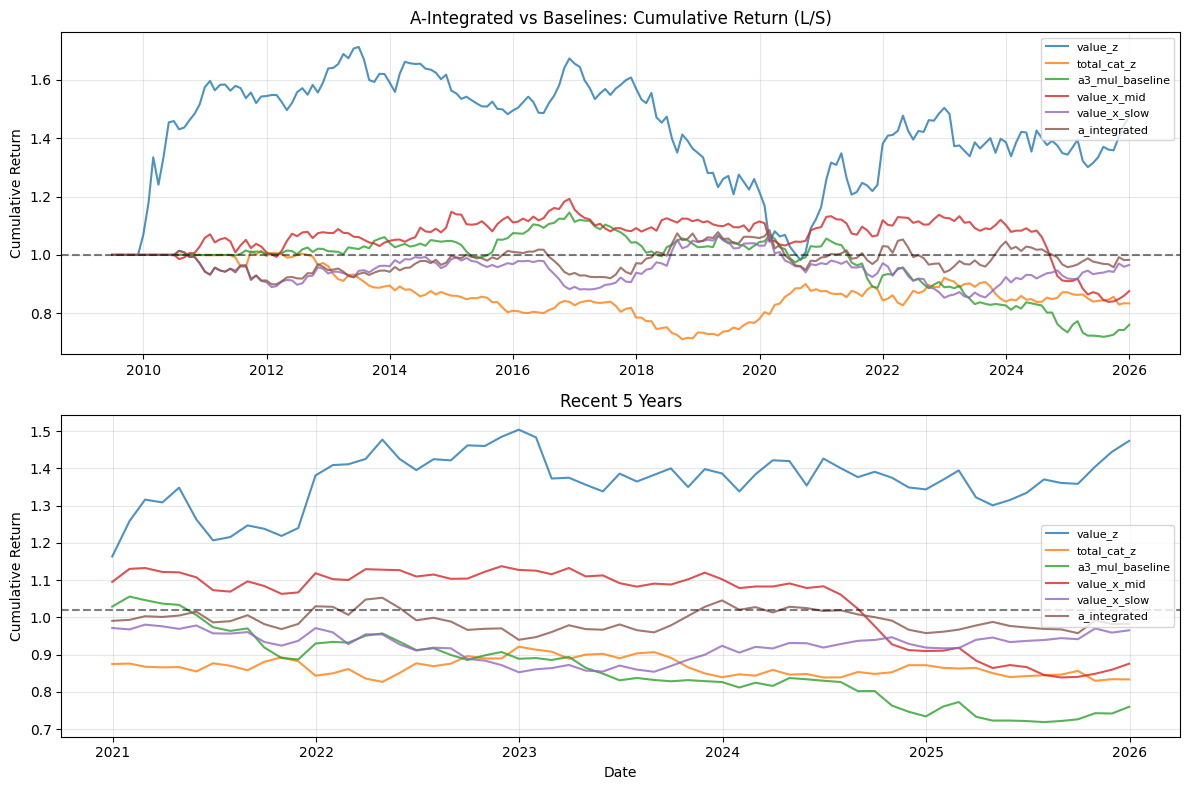


=== 결과 해석 가이드 ===

1. a_integrated > a3_mul_baseline 이면:
   → 속도별 가중 구조가 단순 촉매보다 낫다

2. value_x_slow > value_x_mid 이면:
   → 느린 촉매(재무구조 개선)가 더 저평가되어 있다는 증거

3. t_stat > 1.96 이면:
   → 95% 신뢰수준에서 통계적으로 유의함

4. 전부 음수라도 value_z보다 나으면:
   → "Value만으로는 안 된다"는 A-3 가설의 방향은 맞다
   → 촉매 정의를 더 정교화할 여지가 있다


✅ [셀 7] A-Integrated 분석 완료


In [7]:
# =========================================
# [셀 7] A-Integrated: 속도별 촉매 가중 + Value 결합
# =========================================
# 목적:
#   - A-3의 촉매를 반영 속도별로 분리 (fast/mid/slow)
#   - 늦게 반영되는 촉매일수록 강하게 가중 (시장이 덜 반영했다는 가정)
#   - Value × 가중촉매 = A-integrated
#
# 산출물:
#   - panel_integ: 확장 패널 (a_integrated 신호 포함)
#   - bt_integ: 백테스트 결과
#   - summary_integ: 성과 비교 테이블
#
# 주의:
#   - fast catalyst (실적 서프라이즈): 컨센서스 데이터 없음 → 0으로 처리 (데이터 생기면 교체)
#   - 이 셀은 셀 5 실행 후 실행해야 함 (panel, val, cat_panel 등 필요)

# -----------------------------
# 1) 촉매 속도별 분리 (fund_a 기반)
# -----------------------------

def build_catalyst_by_speed(fund_annual: pd.DataFrame) -> pd.DataFrame:
    """
    촉매를 반영 속도별로 분리
    - fast: 실적 서프라이즈 (데이터 없음 → 0)
    - mid: 수익성 개선 (ROE 변화, 영업이익률 변화)
    - slow: 재무구조 개선 (부채비율 개선, 현금비율 개선)
    
    반환: DataFrame (ticker, fy, fast_cat, mid_cat, slow_cat, total_cat)
    """
    df = fund_annual.copy()
    df = df.sort_values(["ticker", "fy"])
    
    # 숫자형 강제
    num_cols = ["NetIncomeLoss", "CFO", "Revenue", "Assets", 
                "StockholdersEquity", "Liabilities", "CapEx"]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # -----------------------------
    # (A) Fast Catalyst: 실적 서프라이즈
    # -----------------------------
    # 컨센서스 데이터 없음 → 0으로 처리
    # 향후 Refinitiv/Bloomberg 데이터 붙으면 여기서 계산
    df["fast_cat"] = 0.0
    
    # -----------------------------
    # (B) Mid Catalyst: 수익성 개선
    # -----------------------------
    # ROE = NetIncome / Equity (lagged)
    # 영업이익률 ≈ NetIncome / Revenue (근사, OPM 없으니까)
    
    # ROE 계산 (전기 Equity 사용해야 하지만, 단순히 당기로 근사)
    eq = df["StockholdersEquity"].replace(0, np.nan)
    df["roe"] = df["NetIncomeLoss"] / eq
    
    # 순이익률 (OPM 대용)
    rev = df["Revenue"].replace(0, np.nan)
    df["npm"] = df["NetIncomeLoss"] / rev  # Net Profit Margin
    
    # 변화량 (개선)
    df["d_roe"] = df.groupby("ticker")["roe"].diff(1)
    df["d_npm"] = df.groupby("ticker")["npm"].diff(1)
    
    # 스케일 정규화 (연도별)
    for col in ["d_roe", "d_npm"]:
        df[col] = df.groupby("fy")[col].transform(lambda s: winsorize(s, 0.01, 0.99))
    
    # Mid catalyst = 0.6*ROE개선 + 0.4*NPM개선
    df["mid_cat"] = (
        0.6 * df["d_roe"].fillna(0) +
        0.4 * df["d_npm"].fillna(0)
    )
    
    # -----------------------------
    # (C) Slow Catalyst: 재무구조 개선
    # -----------------------------
    # 부채비율 = Liabilities / Equity → 하락이 좋음 → 부호 반전
    # 현금비율 ≈ CFO / Liabilities → 상승이 좋음
    
    liab = df["Liabilities"].replace(0, np.nan)
    
    # 부채비율
    df["debt_ratio"] = liab / eq
    df["d_debt_ratio"] = df.groupby("ticker")["debt_ratio"].diff(1)
    # 부채비율 하락 = 개선 → 부호 반전
    df["d_debt_ratio_inv"] = -df["d_debt_ratio"]
    
    # 현금비율 (CFO/Liabilities)
    df["cash_ratio"] = df["CFO"] / liab
    df["d_cash_ratio"] = df.groupby("ticker")["cash_ratio"].diff(1)
    
    # 스케일 정규화
    for col in ["d_debt_ratio_inv", "d_cash_ratio"]:
        df[col] = df.groupby("fy")[col].transform(lambda s: winsorize(s, 0.01, 0.99))
    
    # Slow catalyst = 0.5*부채비율개선 + 0.5*현금비율개선
    df["slow_cat"] = (
        0.5 * df["d_debt_ratio_inv"].fillna(0) +
        0.5 * df["d_cash_ratio"].fillna(0)
    )
    
    # -----------------------------
    # (D) Total Catalyst: 속도별 가중합
    # -----------------------------
    # 가중치: fast 0.2, mid 0.4, slow 0.6 (늦을수록 강하게)
    # 단, fast=0이므로 실질적으로 mid와 slow만
    W_FAST = 0.0   # 데이터 없으니 0
    W_MID = 0.4
    W_SLOW = 0.6
    
    df["total_cat"] = (
        W_FAST * df["fast_cat"] +
        W_MID * df["mid_cat"] +
        W_SLOW * df["slow_cat"]
    )
    
    return df[["ticker", "fy", "fast_cat", "mid_cat", "slow_cat", "total_cat"]]

# 촉매 계산
cat_speed = build_catalyst_by_speed(fund_a)
print(f"✅ 속도별 촉매 계산 완료: {len(cat_speed):,} rows")
print(cat_speed[["fast_cat", "mid_cat", "slow_cat", "total_cat"]].describe().round(4))

# -----------------------------
# 2) FY -> 월말 매핑 (셀3과 동일 로직)
# -----------------------------
cat_speed["effective_date"] = cat_speed["fy"].apply(
    lambda y: map_fy_to_effective_date(y, LAG_DAYS)
)
cat_speed["effective_date"] = pd.to_datetime(cat_speed["effective_date"]).astype("datetime64[ns]")

# 월말 리밸런스에 asof 매핑
cat_integ_panel = []
for t, g in cat_speed.sort_values(["ticker", "effective_date"]).groupby("ticker"):
    g = g.dropna(subset=["effective_date", "total_cat"]).copy()
    if g.empty:
        continue
    
    tmp = pd.DataFrame({"date": common_me.astype("datetime64[ns]")})
    tmp["ticker"] = t
    
    merged = pd.merge_asof(
        tmp.sort_values("date"),
        g[["effective_date", "fast_cat", "mid_cat", "slow_cat", "total_cat"]].sort_values("effective_date"),
        left_on="date",
        right_on="effective_date",
        direction="backward",
        allow_exact_matches=True
    )
    cat_integ_panel.append(merged)

cat_integ_panel = pd.concat(cat_integ_panel, ignore_index=True)
cat_integ_panel = cat_integ_panel.dropna(subset=["total_cat"]).copy()

# 횡단면 z-score
for col in ["mid_cat", "slow_cat", "total_cat"]:
    tmpz = cat_integ_panel.rename(columns={col: "signal"})
    cat_integ_panel[f"{col}_z"] = zscore_by_date(tmpz, val_col="signal")

print(f"✅ 속도별 촉매 패널 생성: {len(cat_integ_panel):,} rows, {cat_integ_panel['ticker'].nunique()} tickers")

# -----------------------------
# 3) Value와 결합 (셀5의 val 재사용)
# -----------------------------
# val에는 date, ticker, value_z가 있음

sig_integ = val[["date", "ticker", "value_z"]].merge(
    cat_integ_panel[["date", "ticker", "mid_cat_z", "slow_cat_z", "total_cat_z"]],
    on=["date", "ticker"],
    how="inner"
)

# A-integrated 신호 생성
sig_integ["a_integrated"] = sig_integ["value_z"] * sig_integ["total_cat_z"]

# 비교용: mid만, slow만
sig_integ["value_x_mid"] = sig_integ["value_z"] * sig_integ["mid_cat_z"]
sig_integ["value_x_slow"] = sig_integ["value_z"] * sig_integ["slow_cat_z"]

# 기존 방식(a3_mul) 재현용 - catalyst_z 붙이기
sig_integ = sig_integ.merge(
    cat_panel[["date", "ticker", "catalyst_z"]],
    on=["date", "ticker"],
    how="left"
)
sig_integ["a3_mul_baseline"] = sig_integ["value_z"] * sig_integ["catalyst_z"].fillna(0)

print(f"✅ A-integrated 신호 생성: {len(sig_integ):,} rows")

# -----------------------------
# 4) 수익률 결합 + 백테스트
# -----------------------------
ret_local = ret_1m.copy()
ret_local["date"] = pd.to_datetime(ret_local["date"]).astype("datetime64[ns]")

panel_integ = sig_integ.merge(ret_local, on=["date", "ticker"], how="inner")
panel_integ = panel_integ.dropna(subset=["ret_1m"])

print(f"✅ 패널 결합 완료: {len(panel_integ):,} rows, {panel_integ['date'].nunique()} dates")

# 백테스트 실행
test_cols = [
    "value_z",           # value only (baseline)
    "total_cat_z",       # catalyst only (속도가중)
    "a3_mul_baseline",   # 기존 A-3 방식
    "value_x_mid",       # value × mid catalyst
    "value_x_slow",      # value × slow catalyst
    "a_integrated"       # value × 속도가중 촉매 (메인)
]

bt_integ = {}
for c in test_cols:
    if c in panel_integ.columns:
        bt_integ[c] = backtest_ls(panel_integ, c)

# -----------------------------
# 5) 성과 요약
# -----------------------------
summary_integ = pd.concat(
    {k: perf_summary(v[k]) for k, v in bt_integ.items()}, 
    axis=1
).T

print("\n" + "="*60)
print("=== A-Integrated 성과 비교 (월 기준, L/S) ===")
print("="*60)
display(summary_integ.round(4))

# -----------------------------
# 6) 통계 검정 (t-stat, IR)
# -----------------------------
def calc_tstat_ir(returns: pd.Series):
    """t-stat과 Information Ratio 계산"""
    r = returns.dropna()
    n = len(r)
    if n < 12:
        return np.nan, np.nan
    
    mean_r = r.mean()
    std_r = r.std()
    
    # t-stat = mean / (std / sqrt(n))
    t_stat = mean_r / (std_r / np.sqrt(n)) if std_r > 0 else np.nan
    
    # IR (월간) = mean / std * sqrt(12)  (연환산)
    ir = (mean_r / std_r) * np.sqrt(12) if std_r > 0 else np.nan
    
    return t_stat, ir

stats_table = []
for name, bt_df in bt_integ.items():
    ret_series = bt_df[name]
    t_stat, ir = calc_tstat_ir(ret_series)
    stats_table.append({
        "signal": name,
        "t_stat": t_stat,
        "IR_ann": ir,
        "n_months": len(ret_series.dropna()),
        "significant": abs(t_stat) > 1.96 if not np.isnan(t_stat) else False
    })

stats_df = pd.DataFrame(stats_table).set_index("signal")
print("\n=== 통계 검정 결과 ===")
display(stats_df.round(3))

# -----------------------------
# 7) 누적 수익률 시각화
# -----------------------------
import matplotlib.pyplot as plt

cum_integ = pd.concat({k: v["cum"] for k, v in bt_integ.items()}, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# (A) 전체 기간 누적
ax1 = axes[0]
for col in cum_integ.columns:
    ax1.plot(cum_integ.index, cum_integ[col], label=col, alpha=0.8)
ax1.set_title("A-Integrated vs Baselines: Cumulative Return (L/S)", fontsize=12)
ax1.set_ylabel("Cumulative Return")
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(1.0, color="black", linestyle="--", alpha=0.5)

# (B) 최근 5년만
recent_start = cum_integ.index.max() - pd.DateOffset(years=5)
cum_recent = cum_integ[cum_integ.index >= recent_start]

ax2 = axes[1]
for col in cum_recent.columns:
    ax2.plot(cum_recent.index, cum_recent[col], label=col, alpha=0.8)
ax2.set_title("Recent 5 Years", fontsize=12)
ax2.set_ylabel("Cumulative Return")
ax2.set_xlabel("Date")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.axhline(cum_recent.iloc[0].mean(), color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# -----------------------------
# 8) 결과 해석 가이드
# -----------------------------
print("\n" + "="*60)
print("=== 결과 해석 가이드 ===")
print("="*60)
print("""
1. a_integrated > a3_mul_baseline 이면:
   → 속도별 가중 구조가 단순 촉매보다 낫다
   
2. value_x_slow > value_x_mid 이면:
   → 느린 촉매(재무구조 개선)가 더 저평가되어 있다는 증거
   
3. t_stat > 1.96 이면:
   → 95% 신뢰수준에서 통계적으로 유의함
   
4. 전부 음수라도 value_z보다 나으면:
   → "Value만으로는 안 된다"는 A-3 가설의 방향은 맞다
   → 촉매 정의를 더 정교화할 여지가 있다
""")

print("\n✅ [셀 7] A-Integrated 분석 완료")